In [7]:
# 🖼 Dataset & Transforms
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 🔧 Core PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# 📈 Visualization
import matplotlib.pyplot as plt

# 🔣 Math utilities
import math

# 🧪 Optional: If using Curvy or Hessian
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.Imagenette(root='./data', split='train', transform=transform, download=True)
test_dataset = datasets.Imagenette(root='./data', split='val', transform=transform, download=True)


In [9]:

def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=True):
    # Adapted from MAE paper: https://github.com/facebookresearch/mae
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_w, grid_h, indexing='ij')  # (H, W)
    grid = torch.stack(grid, dim=0)  # (2, H, W)
    grid = grid.reshape(2, 1, grid_size, grid_size)
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = torch.cat([torch.zeros([1, embed_dim]), pos_embed], dim=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 4 == 0
    emb_h = get_1d_sincos_pos_embed(embed_dim // 2, grid[0])  # x
    emb_w = get_1d_sincos_pos_embed(embed_dim // 2, grid[1])  # y
    return torch.cat([emb_h, emb_w], dim=1)

def get_1d_sincos_pos_embed(embed_dim, pos):
    omega = torch.arange(embed_dim // 2, dtype=torch.float32)
    omega /= embed_dim / 2.
    omega = 1. / (10000 ** omega)  # (dim/2,)

    pos = pos.reshape(-1)  # flatten
    out = torch.einsum('p,d->pd', pos, omega)  # (pos, dim/2)

    emb_sin = torch.sin(out)
    emb_cos = torch.cos(out)
    return torch.cat([emb_sin, emb_cos], dim=1)  # (pos, dim)

class SimpleViT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=10, dim=256, depth=4, heads=4, mlp_dim=512):
        super().__init__()
        assert image_size % patch_size == 0, 'Image dimensions must be divisible by patch size.'

        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        patch_dim = 3 * patch_size * patch_size

        self.patch_embedding = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim), requires_grad=True)
        pos_embed = get_2d_sincos_pos_embed(dim, int(math.sqrt(self.num_patches)))
        self.register_buffer('pos_embedding', pos_embed.unsqueeze(0))  # [1, num_patches+1, dim]

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p).contiguous()
        x = x.view(B, C, -1, p, p).permute(0, 2, 1, 3, 4)
        x = x.reshape(B, self.num_patches, -1)
        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding

        x = self.transformer(x)
        return self.mlp_head(x[:, 0])


In [12]:
def train_vit(optimizer_class, use_curvy=False, batch_size=128, **optimizer_kwargs):
	device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
	test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

	model = SimpleViT(image_size=224, patch_size=16, num_classes=10)
	model = model.to(device)

	if use_curvy:
		optimizer = optimizer_class(model.parameters(), model=model, **optimizer_kwargs)
	else:
		optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

	criterion = nn.CrossEntropyLoss()
	num_epochs = 20
	train_losses, test_losses = [], []

	for epoch in range(num_epochs):
		model.train()
		train_loss = 0.0
		for data, target in train_loader:
			data, target = data.to(device), target.to(device)
			optimizer.zero_grad()
			output = model(data)
			loss = criterion(output, target)
			loss.backward()
			optimizer.step()
			train_loss += loss.item()
		train_loss /= len(train_loader)
		train_losses.append(train_loss)

		model.eval()
		test_loss, total, total_correct = 0.0, 0, 0
		with torch.no_grad():
			for data, target in test_loader:
				data, target = data.to(device), target.to(device)
				output = model(data)
				loss = criterion(output, target)
				test_loss += loss.item()
				_, predicted = output.max(1)
				total += target.size(0)
				total_correct += predicted.eq(target).sum().item()
		test_loss /= len(test_loader)
		test_losses.append(test_loss)

		print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {total_correct/total:.4f}')

	plt.figure(figsize=(10, 6))
	plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
	plt.plot(range(1, num_epochs+1), test_losses, label='Testing Loss')
	plt.xlabel('Epoch')
	plt.ylabel('Loss')
	plt.title('Training and Testing Loss Curves')
	plt.legend()
	plt.grid(True)
	plt.show()

	return model, train_losses, test_losses


Epoch 1/20, Train Loss: 2.1715, Test Loss: 2.0469, Test Accuracy: 0.2792
Epoch 2/20, Train Loss: 1.9313, Test Loss: 1.8212, Test Accuracy: 0.3725
Epoch 3/20, Train Loss: 1.7403, Test Loss: 1.6604, Test Accuracy: 0.4288
Epoch 4/20, Train Loss: 1.5845, Test Loss: 1.6451, Test Accuracy: 0.4423
Epoch 5/20, Train Loss: 1.5656, Test Loss: 1.4726, Test Accuracy: 0.5157
Epoch 6/20, Train Loss: 1.4873, Test Loss: 1.4620, Test Accuracy: 0.5131
Epoch 7/20, Train Loss: 1.4426, Test Loss: 1.4678, Test Accuracy: 0.5126
Epoch 8/20, Train Loss: 1.3906, Test Loss: 1.4813, Test Accuracy: 0.5027
Epoch 9/20, Train Loss: 1.3705, Test Loss: 1.4388, Test Accuracy: 0.5241
Epoch 10/20, Train Loss: 1.3706, Test Loss: 1.4046, Test Accuracy: 0.5284
Epoch 11/20, Train Loss: 1.3184, Test Loss: 1.3116, Test Accuracy: 0.5646
Epoch 12/20, Train Loss: 1.2861, Test Loss: 1.3291, Test Accuracy: 0.5541
Epoch 13/20, Train Loss: 1.2715, Test Loss: 1.2972, Test Accuracy: 0.5633
Epoch 14/20, Train Loss: 1.2160, Test Loss: 1.2

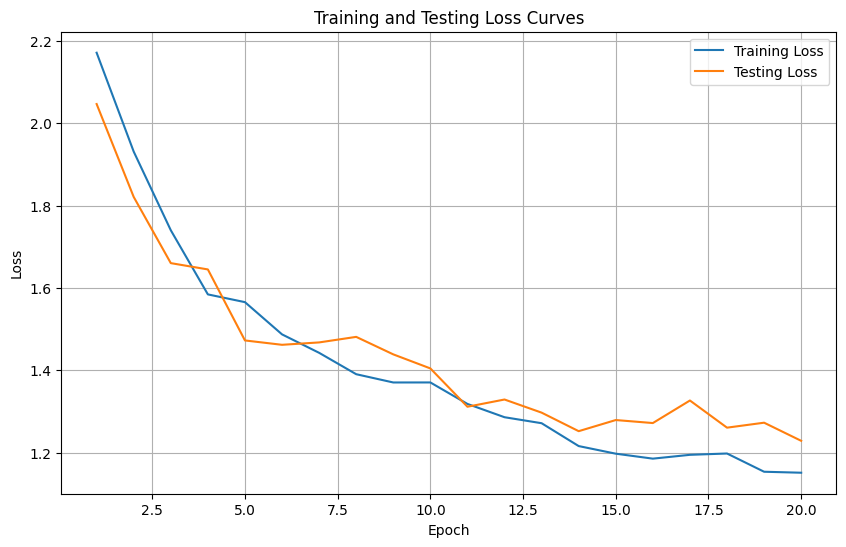

In [11]:
model, train_losses, test_losses = train_vit(optim.Adam, lr=1e-3)

/home/aarsh.wankar/Hessian/DeepHessian/Curvy/curvy.py:64: UserWarning: Hessian computation function, criterion, or data loader not provided. Curvature-based scaling will be disabled.
  warnings.warn(


Epoch 1/20, Train Loss: 2.1984, Test Loss: 2.1159, Test Accuracy: 0.2507
Epoch 2/20, Train Loss: 2.0881, Test Loss: 2.0654, Test Accuracy: 0.2668
Epoch 3/20, Train Loss: 2.0398, Test Loss: 2.0184, Test Accuracy: 0.2808
Epoch 4/20, Train Loss: 1.9846, Test Loss: 1.9627, Test Accuracy: 0.3047
Epoch 5/20, Train Loss: 1.9384, Test Loss: 1.9110, Test Accuracy: 0.3282
Epoch 6/20, Train Loss: 1.8955, Test Loss: 1.8843, Test Accuracy: 0.3432
Epoch 7/20, Train Loss: 1.8545, Test Loss: 1.8534, Test Accuracy: 0.3460
Epoch 8/20, Train Loss: 1.8140, Test Loss: 1.8001, Test Accuracy: 0.3689
Epoch 9/20, Train Loss: 1.7949, Test Loss: 1.8066, Test Accuracy: 0.3806
Epoch 10/20, Train Loss: 1.7557, Test Loss: 1.7847, Test Accuracy: 0.3753
Epoch 11/20, Train Loss: 1.7261, Test Loss: 1.7195, Test Accuracy: 0.4005
Epoch 12/20, Train Loss: 1.7027, Test Loss: 1.6991, Test Accuracy: 0.4031
Epoch 13/20, Train Loss: 1.6676, Test Loss: 1.6608, Test Accuracy: 0.4239
Epoch 14/20, Train Loss: 1.6446, Test Loss: 1.6

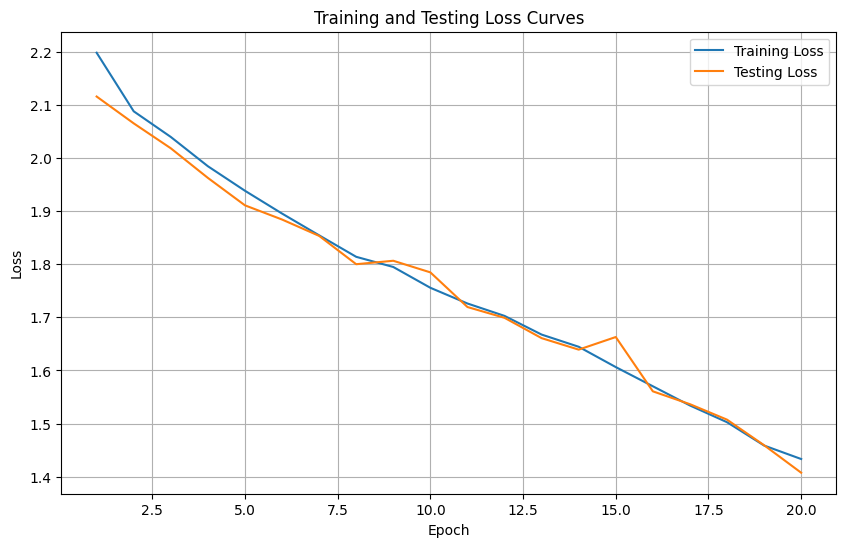

In [15]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import torch.nn as nn

curvy_model, curvy_train, curvy_test = train_vit(
    optimizer_class=Curvy,
    use_curvy=True,
    lr=1e-3,
    hessian_epsilon=1e-3,
    momentum=0.9,
    hessian_compute_interval=50,
    hessian_n_iter=100,
    criterion=nn.CrossEntropyLoss(),
    hessian_computer=hessian,
    # train_x=train_dataset.data,
    # train_y=train_dataset.labels,
    cuda=True
)


/home/aarsh.wankar/Hessian/DeepHessian/Curvy/curvy.py:64: UserWarning: Hessian computation function, criterion, or data loader not provided. Curvature-based scaling will be disabled.
  warnings.warn(


Epoch 1/20, Train Loss: 2.1703, Test Loss: 2.0774, Test Accuracy: 0.2433
Epoch 2/20, Train Loss: 2.0416, Test Loss: 1.9825, Test Accuracy: 0.2910
Epoch 3/20, Train Loss: 1.9628, Test Loss: 1.9408, Test Accuracy: 0.3152
Epoch 4/20, Train Loss: 1.9066, Test Loss: 1.8567, Test Accuracy: 0.3508
Epoch 5/20, Train Loss: 1.8303, Test Loss: 1.8042, Test Accuracy: 0.3664
Epoch 6/20, Train Loss: 1.7644, Test Loss: 1.7149, Test Accuracy: 0.4104
Epoch 7/20, Train Loss: 1.6898, Test Loss: 1.6551, Test Accuracy: 0.4341
Epoch 8/20, Train Loss: 1.6180, Test Loss: 1.5796, Test Accuracy: 0.4606
Epoch 9/20, Train Loss: 1.5491, Test Loss: 1.5489, Test Accuracy: 0.4808
Epoch 10/20, Train Loss: 1.4955, Test Loss: 1.4795, Test Accuracy: 0.5019
Epoch 11/20, Train Loss: 1.4470, Test Loss: 1.4376, Test Accuracy: 0.5225
Epoch 12/20, Train Loss: 1.4025, Test Loss: 1.4317, Test Accuracy: 0.5261
Epoch 13/20, Train Loss: 1.3836, Test Loss: 1.3690, Test Accuracy: 0.5429
Epoch 14/20, Train Loss: 1.3365, Test Loss: 1.3

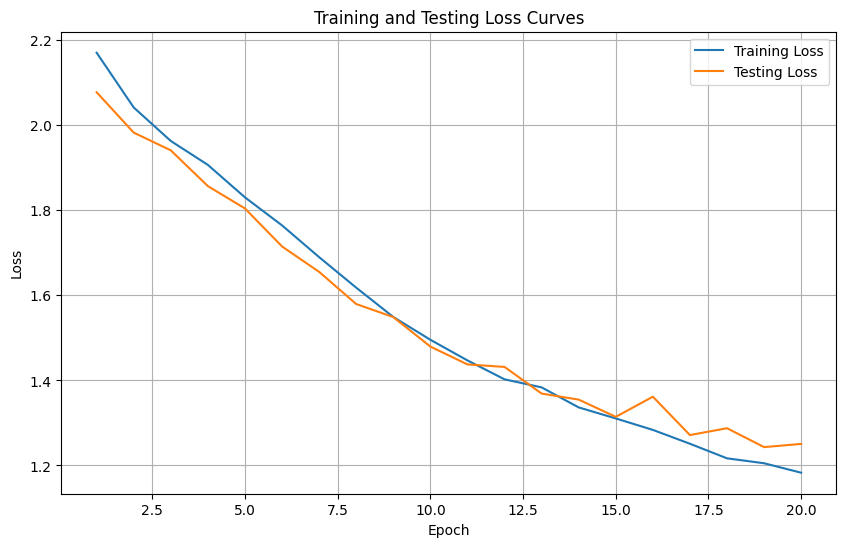

In [17]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import torch.nn as nn

curvy_model, curvy_train, curvy_test = train_vit(
    optimizer_class=Curvy,
    use_curvy=True,
    lr=4e-3,
    hessian_epsilon=4e-5,
    momentum=0.8,
    hessian_compute_interval=200,
    hessian_n_iter=100,
    criterion=nn.CrossEntropyLoss(),
    hessian_computer=hessian,
    # train_x=train_dataset.data,
    # train_y=train_dataset.labels,
    cuda=True
)
